# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [13]:
# importa las librerías
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpl
from sklearn.cluster import KMeans

#### 2. Lee las imagenes
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [14]:
imagen = mpl.imread("./ladybug.png")
imagen.shape

(533, 800, 3)

Muestra la imagen para ver que se ha cargado bien

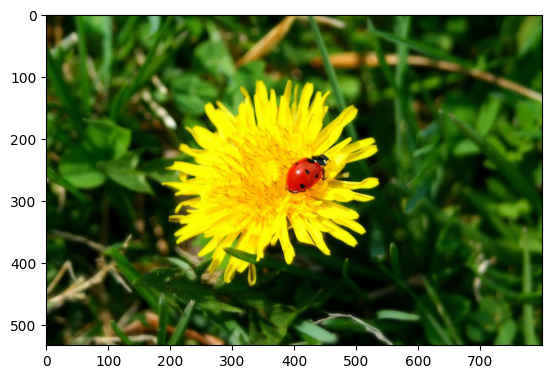

In [15]:
plt.imshow(imagen)

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [16]:
# modifica las dimensiones del numpy array
imagen2 = imagen.reshape(426400, 3)

#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [17]:
# kmeans con 8 centroides por ejemplo, semilla 42 y 10 repeticiones del kmeans para elegir los centroides que acaban con la mejor inercia
kmeans = KMeans(n_clusters= 8, random_state=42, max_iter= 10)
# ajústalo a tus datos
imagen_nueva = kmeans.fit_predict(imagen2)
imagen_nueva

array([0, 0, 0, ..., 0, 0, 0], shape=(426400,), dtype=int32)

#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizas para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [18]:
clusters = kmeans.cluster_centers_
labels = kmeans.labels_

print(clusters.shape)
print(labels.shape)

imagen_nueva = clusters[labels]
imagen_nueva

(8, 3)
(426400,)


array([[0.03092703, 0.1299058 , 0.00666662],
       [0.03092703, 0.1299058 , 0.00666662],
       [0.03092703, 0.1299058 , 0.00666662],
       ...,
       [0.03092703, 0.1299058 , 0.00666662],
       [0.03092703, 0.1299058 , 0.00666662],
       [0.03092703, 0.1299058 , 0.00666662]],
      shape=(426400, 3), dtype=float32)

#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [19]:
# hay que volver a hacer la imagen rectangular, no una ristra de píxeles
imagen_nueva = imagen_nueva.reshape(533, 800, 3)

#### 7. Imprime y guarda en tu ordenador la imagen resultante

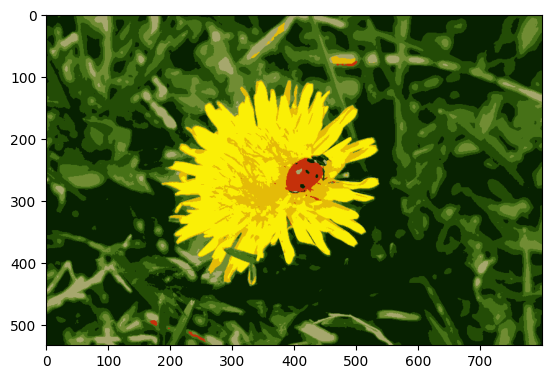

In [20]:
plt.imshow(imagen_nueva)

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [21]:
print(imagen_nueva.shape[0])
print(imagen_nueva.shape[1])
print(imagen_nueva.shape[2])

533
800
3


In [22]:
def imagen_mod(imagen, n_colores, save = True):
    kmeans = KMeans(n_clusters= n_colores, random_state= 42, max_iter= 10)
    n1 = imagen.shape[0]
    n2 = imagen.shape[1]
    n3 = imagen.shape[2]
    new_shape = (n1 * n2, n3)
    imagen = imagen.reshape(new_shape)

    imagen_mod = kmeans.fit_predict(imagen)
    clusters = kmeans.cluster_centers_
    labels = kmeans.labels_

    imagen_mod = clusters[labels]

    imagen_mod = imagen_mod.reshape(n1, n2, 3)

    if save == True:
        return imagen_mod
    else:
        return plt.imshow(imagen_mod)
# crea una función que dada una imagen, una cantidad de colores y si se quiere guardar la imagen modificada o solo mostrarla, que siga esos pasos

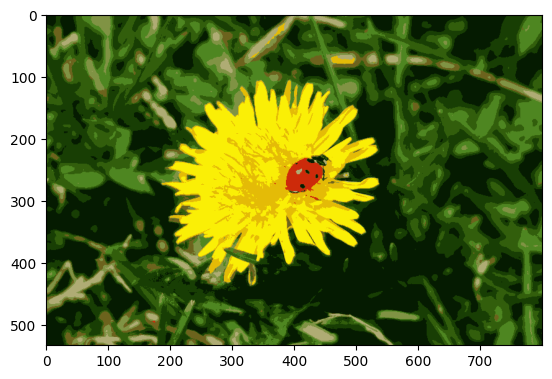

In [26]:
imagen_mod(imagen, 10, save=False)